In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
ds = load_dataset("regicid/LRFAF", split="train")
df = pd.DataFrame(ds)

# Quick overview
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f}GB")

# Check data quality
print(df.info())
print(df.describe())

# Null values
print(df.isnull().sum())

Shape: (37307, 33)
Columns: ['artist', 'title', 'year', 'lyrics', 'pageviews', 'contributors', 'url', 'topic', 'topic_clean', 'ranking', 'n_je', 'n_profanity', 'n_verlan', 'n_french_words', 'means_word_length', 'n_unique_words', 'n_words', 'pageviews_corrected', 'n_non_french_words', 'n_argot', 'n_onomatopee', 'n_negative', 'n_positive', 'birthdate_artist', 'age_artist', 'pageview_mean', 'pageviews_2', 'n_sexe', 'hate', 'sexism', 'n_lines', 'sentiment2', 'born_in_france']
Memory usage: 0.19GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37307 entries, 0 to 37306
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   artist               37307 non-null  object 
 1   title                37307 non-null  object 
 2   year                 33696 non-null  float64
 3   lyrics               37307 non-null  object 
 4   pageviews            37307 non-null  int64  
 5   contributors         37307 non-null  i

In [3]:
len(df[df.year.isna()])

3611

<Axes: xlabel='n_words', ylabel='Count'>

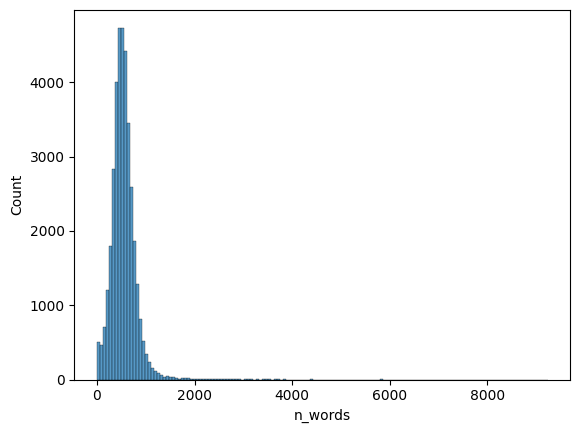

In [34]:

sns.histplot(df['n_words'], bins = 150)

In [39]:
df[df['n_words']<100]["lyrics"].tolist()

["\n(Rires)\nNous allons tester les micros un par un, d'abord le mien...\n(Rires)\nCelui à Joey, c'est bon ?",
 '\nCe morceau est dédicacé à tous ceux\nQui pendant des années nous ont supporté\nNous ont épaulé, ouais\nA tous nos coéquipiers\n93 Nique Ta Mère\nEt la mère patrie dévisse un peu son règne',
 "La mort frappera sans retard ceux\nQui oseront troubler le sommeil éternel du pharaon\nEt puis un jour il y a eu autre chose\nPharaon revient pour régner sur la haute et la basse Égypte\nAutrement dit sur l'univers\nLa splendeur de la civilisation règne de proche en proche vers l'océan\nMarseille, l'imagination s'arrête\nCette terre est réputée être la première à avoir émerger des eaux originelles 1",
 "Quand on fume du crack on sait pu très bien ce qu'on fait",
 '\nJaaaazz !\n(riff de saxo)',
 "Eh bien bonsoir à tous et à toutes\nBienvenue ce soir au New Star Flash Night Laser Light Action Club\nEn compagnie de votre DJ préféré\nOK, alors un maximum d'ambiance garantie\nPour cette su

In [44]:
from french_rap_lyrics_cleaner import flag_non_songs
df = flag_non_songs(df)
songs_to_remove = (~df['is_song_candidate']).sum()

   Flagged 245 entries with missing/incomplete lyrics markers
   Flagged 429 entries that are too short
   Flagged 32 entries with missing lyrics data
   Flagged 8895 entries with suspicious engagement patterns
   Flagged 6 instrumental tracks


In [43]:
non_lyric_keywords = ['Cliquez ici pour un meilleur aperçu', 'lyrics à venir', 'yet to be transcribed', '(À COMPLÉTER)',"Cette piste est une instrumentale de","Missing song info","équipe Rap Genius France"]
mask_keywords = df['lyrics'].str.lower().str.contains('|'.join(non_lyric_keywords), na=False)
df.loc[mask_keywords, 'is_lyrics_candidate'] = False

df[df['is_lyrics_candidate']==False]["lyrics"].tolist()

/tmp/ipykernel_43715/2842747825.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_keywords = df['lyrics'].str.lower().str.contains('|'.join(non_lyric_keywords), na=False)


['The lyrics for this song have yet to be transcribed',
 'Track 16 lyrics à venir',
 'Lyrics à venir',
 'Lyrics à venir',
 'The lyrics for this song have yet to be transcribed',
 'The lyrics for this song have yet to be transcribed',
 'The lyrics for this song have yet to be transcribed',
 'The lyrics for this song have yet to be transcribed']

In [ ]:
# Flag suspicious documents
df['is_lyrics_candidate'] = True
suspicious_count = 0

# Criterion 1: Minimum length
min_words = 50
mask_short = df['n_words'] < min_words
df.loc[mask_short, 'is_lyrics_candidate'] = False
print(f"Removed {mask_short.sum()} documents: too short ({min_words}< words)")
suspicious_count += mask_short.sum()

# Criterion 2: French content ratio
min_french_ratio = 0.3
df['french_ratio'] = df['n_french_words'] / (df['n_words'] + 1)
mask_french = df['french_ratio'] < min_french_ratio
df.loc[mask_french, 'is_lyrics_candidate'] = False
print(f"Removed {mask_french.sum()} documents: insufficient French content")
suspicious_count += mask_french.sum()

# Criterion 3: Metadata markers
non_lyric_keywords = ['(Cliquez ici pour un meilleur aperçu)', 'interview', 'embed', 'sample', 'instrumental']
mask_keywords = df['lyrics'].str.lower().str.contains('|'.join(non_lyric_keywords), na=False)
df.loc[mask_keywords, 'is_lyrics_candidate'] = False
print(f"Removed {mask_keywords.sum()} documents: contains metadata keywords")
suspicious_count += mask_keywords.sum()

# Clean dataset
df_clean = df[df['is_lyrics_candidate']].copy()
print(f"\nTotal removed: {suspicious_count} ({suspicious_count/len(df)*100:.1f}%)")
print(f"Remaining: {len(df_clean)} valid lyrics documents")

# Drop temporary columns
df_clean = df_clean.drop(['is_lyrics_candidate', 'french_ratio'], axis=1)

Removed 418 documents: too short (50< words)
Removed 78 documents: insufficient French content
Removed 1429 documents: contains metadata keywords

Total removed: 1925 (5.2%)
Remaining: 35481 valid lyrics documents


In [3]:
# Critical fields - check for nulls
critical_fields = ['artist', 'title', 'lyrics', 'year', 'n_words']
print("Missing values in critical fields:")
print(df_clean[critical_fields].isnull().sum())

# Handle missing years using artist median
df_clean['year'] = df_clean.groupby('artist')['year'].transform(
    lambda x: x.fillna(x.median())
)

# Fill remaining years with global median
df_clean['year'] = df_clean['year'].fillna(df_clean['year'].median())

# Topic: fill unknown with 'Autres'
df_clean['topic_clean'] = df_clean['topic_clean'].fillna('Autres')

# Check again
print("\nAfter imputation:")
print(df_clean[critical_fields].isnull().sum())

Missing values in critical fields:
artist        0
title         0
lyrics        0
year       3150
n_words       0
dtype: int64

After imputation:
artist     0
title      0
lyrics     0
year       0
n_words    0
dtype: int64


/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/robin/env/rap_fr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1

In [4]:
import re
import unicodedata

def normalize_lyrics(text):
    """Comprehensive text normalization"""
    if not isinstance(text, str):
        return ""
    
    # 1. Normalize unicode
    text = unicodedata.normalize('NFC', text)
    
    # 2. Fix common encoding issues
    replacements = {
        'Ã©': 'é', 'Ã¨': 'è', 'Ã': 'ê', 'Ã«': 'ë',
        'Ã ': 'à', 'Ã§': 'ç', 'Ã¹': 'ù', 'Û': 'û',
        '&amp;': '&', '&quot;': '"', '&apos;': "'",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    # 3. Standardize quotes
    text = re.sub(r'["""]', '"', text)
    text = re.sub(r"[''']", "'", text)
    
    # 4. Fix spacing around punctuation
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'([.,!?;:])(?! )', r'\1 ', text)
    
    # 5. Normalize whitespace (preserve line breaks)
    lines = text.split('\n')
    lines = [' '.join(line.split()) for line in lines]  # Collapse internal spaces
    text = '\n'.join(lines)
    
    # 6. Remove control characters
    text = ''.join(char for char in text if unicodedata.category(char) != 'C')
    
    # 7. Trim leading/trailing whitespace
    text = text.strip()
    
    return text

# Apply normalization
print("Normalizing lyrics...")
df_clean['lyrics_normalized'] = df_clean['lyrics'].apply(normalize_lyrics)

# Verify
print("Sample normalized lyric:")
print(df_clean['lyrics_normalized'].iloc[:200])

Normalizing lyrics...
Sample normalized lyric:
0      Paname city rappin', c'est le Paname city rap\...
1      En force, Asiatic attaque en rimes\nDéclarant ...
2      Quand ce sera la fin d'la musique, tu tireras....
3      Aton almighty la rentrée sur le beat\nMarquant...
4      "Ain't no other alternative"\n\nIls traquent, ...
                             ...                        
224    Tout n'est pas si facile, tout ne tient qu'à u...
225    "Je suis un créancier très patient\nQuand l’éc...
226    L'argent pourrit les gens, je serai pourri jus...
227    Mais qu'est-ce, mais qu'est-ce qu'on attend po...
228    All right\n\nToujours prêt quand faut rouler u...
Name: lyrics_normalized, Length: 200, dtype: object


In [5]:
import re
from collections import defaultdict

def extract_verses_from_lyrics(lyrics, artist="", title=""):
    """
    Smart verse extraction with multiple strategies
    Returns: list of (verse_text, verse_type, confidence)
    """
    if not lyrics or len(lyrics.strip()) < 20:
        return []
    
    verses = []
    
    # STRATEGY 1: Explicit markers (highest confidence)
    marker_pattern = r'\[([^\]]+)\]'
    markers = list(re.finditer(marker_pattern, lyrics))
    
    if len(markers) >= 2:  # Has structure markers
        for i, match in enumerate(markers):
            label = match.group(1).lower()
            
            # Classify marker
            verse_type = 'verse'  # default
            if any(x in label for x in ['verse', 'couplet', 'couplet']):
                verse_type = 'verse'
            elif any(x in label for x in ['chorus', 'refrain', 'hook']):
                verse_type = 'chorus'
            elif any(x in label for x in ['bridge', 'pont']):
                verse_type = 'bridge'
            elif any(x in label for x in ['intro']):
                verse_type = 'intro'
            elif any(x in label for x in ['outro']):
                verse_type = 'outro'
            elif any(x in label for x in ['feat', 'ft']):
                verse_type = 'feature'
            
            # Extract text between this marker and next
            start = match.end()
            next_marker = markers[i + 1] if i + 1 < len(markers) else None
            end = next_marker.start() if next_marker else len(lyrics)
            
            verse_text = lyrics[start:end].strip()
            
            if verse_text and len(verse_text.split()) > 3:
                verses.append({
                    'text': verse_text,
                    'type': verse_type,
                    'confidence': 0.95,
                    'strategy': 'explicit_markers',
                    'lines': len(verse_text.split('\n'))
                })
        
        return verses  # Stop if we found structured lyrics
    
    # STRATEGY 2: Double newline separation
    sections = re.split(r'\n\s*\n+', lyrics)
    if len(sections) >= 2:
        for idx, section in enumerate(sections):
            section = section.strip()
            if len(section.split()) > 5:  # Minimum threshold
                # Infer type from position
                if idx == 0:
                    verse_type = 'intro'
                elif idx == len(sections) - 1:
                    verse_type = 'outro'
                else:
                    verse_type = 'verse'
                
                verses.append({
                    'text': section,
                    'type': verse_type,
                    'confidence': 0.75,
                    'strategy': 'double_newlines',
                    'lines': len(section.split('\n'))
                })
        
        if verses:
            return verses
    
    # STRATEGY 3: Chorus detection (repeated lines)
    lines = [l.strip() for l in lyrics.split('\n') if l.strip()]
    line_counter = defaultdict(list)
    
    for idx, line in enumerate(lines):
        if len(line) > 15:  # Ignore very short lines
            # Normalize for comparison
            normalized = re.sub(r'\s+', ' ', line.lower())
            line_counter[normalized].append(idx)
    
    repeated_lines = {line: indices for line, indices in line_counter.items() 
                     if len(indices) >= 3}
    
    if repeated_lines:
        # Mark repeated lines as chorus
        verse_lines = []
        for idx, line in enumerate(lines):
            normalized = re.sub(r'\s+', ' ', line.lower())
            if normalized in repeated_lines:
                if verse_lines:
                    verse_text = '\n'.join(verse_lines)
                    verses.append({
                        'text': verse_text,
                        'type': 'verse',
                        'confidence': 0.65,
                        'strategy': 'chorus_detection',
                        'lines': len(verse_lines)
                    })
                    verse_lines = []
                verses.append({
                    'text': line,
                    'type': 'chorus',
                    'confidence': 0.85,
                    'strategy': 'chorus_detection',
                    'lines': 1
                })
            else:
                verse_lines.append(line)
        
        if verse_lines:
            verses.append({
                'text': '\n'.join(verse_lines),
                'type': 'verse',
                'confidence': 0.65,
                'strategy': 'chorus_detection',
                'lines': len(verse_lines)
            })
        
        if verses:
            return verses
    
    # STRATEGY 4: Heuristic fallback (lowest confidence)
    # Group into ~12 line chunks (typical verse length)
    chunk_size = 12
    for chunk_idx in range(0, len(lines), chunk_size):
        chunk = lines[chunk_idx:chunk_idx + chunk_size]
        if chunk:
            verse_text = '\n'.join(chunk)
            verses.append({
                'text': verse_text,
                'type': 'verse',
                'confidence': 0.40,
                'strategy': 'heuristic_chunks',
                'lines': len(chunk)
            })
    
    return verses

# Extract verses for each song
print("Extracting verses from all songs...")
all_verses = []

for idx, row in df_clean.iterrows():
    if idx % 5000 == 0:
        print(f"  Processing song {idx}/{len(df_clean)}")
    
    verses_data = extract_verses_from_lyrics(
        row['lyrics_normalized'],
        row['artist'],
        row['title']
    )
    
    for verse_num, verse_info in enumerate(verses_data, 1):
        verse_record = {
            'artist': row['artist'],
            'title': row['title'],
            'year': row['year'],
            'topic_clean': row['topic_clean'],
            'verse_id': f"{row['artist']}_{row['title']}_{verse_num:03d}".replace(' ', '_'),
            'verse_number': verse_num,
            'verse_type': verse_info['type'],
            'verse_text': verse_info['text'],
            'line_count': verse_info['lines'],
            'word_count': len(verse_info['text'].split()),
            'extraction_strategy': verse_info['strategy'],
            'extraction_confidence': verse_info['confidence']
        }
        all_verses.append(verse_record)

# Create verse-level dataframe
df_verses = pd.DataFrame(all_verses)
print(f"\nExtracted {len(df_verses)} verses from {len(df_clean)} songs")
print(f"Average verses per song: {len(df_verses)/len(df_clean):.2f}")

# Show statistics
print("\nVerse type distribution:")
print(df_verses['verse_type'].value_counts())
print("\nExtraction method distribution:")
print(df_verses['extraction_strategy'].value_counts())
print("\nConfidence distribution:")
print(df_verses['extraction_confidence'].describe())

Extracting verses from all songs...
  Processing song 0/35481
  Processing song 5000/35481
  Processing song 10000/35481
  Processing song 15000/35481
  Processing song 20000/35481
  Processing song 25000/35481
  Processing song 30000/35481
  Processing song 35000/35481

Extracted 191700 verses from 35481 songs
Average verses per song: 5.40

Verse type distribution:
verse_type
verse     117293
outro      30475
intro      28148
chorus     15784
Name: count, dtype: int64

Extraction method distribution:
extraction_strategy
double_newlines     159090
chorus_detection     21108
heuristic_chunks     11492
explicit_markers        10
Name: count, dtype: int64

Confidence distribution:
count    191700.000000
mean          0.734481
std           0.090587
min           0.400000
25%           0.750000
50%           0.750000
75%           0.750000
max           0.950000
Name: extraction_confidence, dtype: float64


In [8]:
df_verses[df_verses["verse_type"]=="chorus"]['verse_text'][:10]

24                        Elle m'a fait: "Bouge de là! "
26                          Il m'a fait: "Bouge de là! "
28                        Elle m'a fait: "Bouge de là! "
30                        Elle m'a fait: "Bouge de là! "
32                          Il m'a fait: "Bouge de là! "
34                          Il m'a fait: "Bouge de là! "
273        Car c'est matière grasse contre matière grise
275        Car c'est matière grasse contre matière grise
277        Car c'est matière grasse contre matière grise
280    Il est trop tard pour s'intéresser à son trist...
Name: verse_text, dtype: object

In [9]:
# Save cleaned song-level data
df_clean.to_csv('data/lrfaf_cleaned_songs.csv', index=False)
print(f"Saved {len(df_clean)} cleaned songs to 'lrfaf_cleaned_songs.csv'")

# Save verse-level data
df_verses.to_csv('data/lrfaf_verses.csv', index=False)
print(f"Saved {len(df_verses)} verses to 'lrfaf_verses.csv'")

# Save summary statistics
summary = {
    'total_songs_original': len(df),
    'total_songs_after_cleaning': len(df_clean),
    'removed_count': len(df) - len(df_clean),
    'removed_percentage': (len(df) - len(df_clean)) / len(df) * 100,
    'total_verses_extracted': len(df_verses),
    'avg_verses_per_song': len(df_verses) / len(df_clean),
    'avg_words_per_verse': df_verses['word_count'].mean(),
    'topic_distribution': df_clean['topic_clean'].value_counts().to_dict(),
    'verse_type_distribution': df_verses['verse_type'].value_counts().to_dict(),
}

import json
with open('data/lrfaf_cleaning_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\nCleaning summary saved to 'lrfaf_cleaning_summary.json'")

Saved 35481 cleaned songs to 'lrfaf_cleaned_songs.csv'
Saved 191700 verses to 'lrfaf_verses.csv'

Cleaning summary saved to 'lrfaf_cleaning_summary.json'


In [11]:
# Quality Assurance: Generate report
print("=== DATA QUALITY REPORT ===\n")

# 1. Duplicate check
duplicate_songs = df_clean.duplicated(subset=['artist', 'title']).sum()
print(f"Duplicate songs: {duplicate_songs}")

# 2. Verse extraction coverage
avg_verses_per_song = len(df_verses) / len(df_clean)
print(f"Average extraction coverage: {avg_verses_per_song:.2f} verses per song")
print(f"Verses successfully extracted: {len(df_verses)}")
print(f"Average extraction coverage: {coverage:.1f}%")

# 3. Year range
print(f"Year range: {df_clean['year'].min():.0f} - {df_clean['year'].max():.0f}")

# 4. Artist coverage
print(f"Unique artists: {df_clean['artist'].nunique()}")

# 5. Verse quality statistics
print(f"\nVerse Statistics:")
print(f"  Min words per verse: {df_verses['word_count'].min()}")
print(f"  Max words per verse: {df_verses['word_count'].max()}")
print(f"  Mean words per verse: {df_verses['word_count'].mean():.1f}")
print(f"  Min lines per verse: {df_verses['line_count'].min()}")
print(f"  Max lines per verse: {df_verses['line_count'].max()}")
print(f"  Mean lines per verse: {df_verses['line_count'].mean():.1f}")

# 6. Extraction confidence
high_conf = (df_verses['extraction_confidence'] >= 0.8).sum()
med_conf = ((df_verses['extraction_confidence'] >= 0.6) & 
            (df_verses['extraction_confidence'] < 0.8)).sum()
low_conf = (df_verses['extraction_confidence'] < 0.6).sum()

print(f"\nExtraction Confidence:")
print(f"  High confidence (≥0.80): {high_conf} ({high_conf/len(df_verses)*100:.1f}%)")
print(f"  Medium confidence (0.60-0.79): {med_conf} ({med_conf/len(df_verses)*100:.1f}%)")
print(f"  Low confidence (<0.60): {low_conf} ({low_conf/len(df_verses)*100:.1f}%)")

=== DATA QUALITY REPORT ===

Duplicate songs: 0
Average extraction coverage: 5.40 verses per song
Verses successfully extracted: 191700
Average extraction coverage: 0.9%
Year range: 1984 - 2024
Unique artists: 611

Verse Statistics:
  Min words per verse: 1
  Max words per verse: 3353
  Mean words per verse: 89.7
  Min lines per verse: 1
  Max lines per verse: 385
  Mean lines per verse: 10.5

Extraction Confidence:
  High confidence (≥0.80): 15790 (8.2%)
  Medium confidence (0.60-0.79): 164418 (85.8%)
  Low confidence (<0.60): 11492 (6.0%)
